# Chapter 7 (extra) -- Quasi-reversible AC & square-wave voltammetry on an expanding grid

The chapter notebook `07_ac_voltammetry.ipynb` treats the **reversible** (Nernstian)
AC and square-wave (SW) responses on a *uniform* space grid. This supplement adds the
chapter's real computational payload, ported from the companion notebooks
`ImplicitACExp.nb`, `ImplicitSWExp1.nb` and `ImplicitSWExp2.nb`:

* **quasi-reversible Butler-Volmer (BV)** AC and SW finite-difference simulators,
  so the standard rate constant $k_s$ controls how reversible the wave looks;
* an **exponentially expanding space grid** -- nodes spaced $x_j\sim a^{\,j}$ so a few
  hundred nodes span many diffusion lengths, which the thousands of tiny AC/SW time
  steps demand;
* the **moving-average DC filter** that strips the AC/SW ripple to recover the
  underlying DC linear-sweep voltammogram;
* **square wave on a linear ramp** vs. **square wave on a staircase** (true SWV);
* **FFT analysis** of the AC/square-wave voltammogram (its harmonic structure).

All of the heavy lifting lives in `serm.ch07_quasireversible_ac_sw`, which reuses the
already-validated BV surface elimination from `serm.kinetics` / `serm.boundary`
(the same one Chapter 6 uses on a uniform grid).

**Validation strategy.** The headline check is a *reduction to a validated limit*:
as $k_s\to\infty$ the BV boundary collapses to the Nernstian Dirichlet condition, so the
expanding-grid AC fundamental must recover the reversible envelope
$\tfrac14\,\mathrm{sech}^2(\eta/2)$ already validated in the chapter notebook. We add an
independent closed-form check (the DC-filtered AC response peaks at the reversible
LSV value $0.4463$). The opposite $k_s\to0$ (strongly irreversible) limit is checked too: the AC fundamental peak collapses to well under half the reversible $1/4$ as the sluggish electrode can no longer follow the AC perturbation. We also add self-consistency checks (FFT fundamental at the cycle-count bin; monotone kinetic broadening; SW difference peak at the formal potential).

In [1]:
import os, sys
# Walk up from the notebook dir until the repo root (the folder containing `serm/`).
_root = os.path.abspath('..')
while not os.path.isdir(os.path.join(_root, 'serm')) and _root != os.path.dirname(_root):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

from serm.kinetics import f_thermal
from serm.boundary import bv_limits_selfcheck
from serm.ch07_quasireversible_ac_sw import (
    expanding_diagonals, expanding_grid_points,
    simulate_ac, simulate_sw_ramp, simulate_sw_staircase, ac_dc_filter,
)

f_RT = f_thermal(298.15)          # f = F/RT (1/V) for n = 1
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 110
print(f'f = F/RT = {f_RT:.3f} 1/V')

f = F/RT = 38.922 1/V


## 1. The expanding space grid

On a uniform grid the cost of resolving the surface gradient forces a small $\Delta x$
*everywhere*, even far out where the concentration is flat. An **expanding grid** places
nodes geometrically, $x_j \propto a^{\,j}$ ($a>1$), so the mesh is fine at the electrode
and coarse in the bulk.

Honeychurch's `makeDiagonals` encodes the resulting non-uniform implicit Laplacian as
three diagonals for interior node $j=2\ldots m-1$,
$$x_j=-D_M\,a^{4-2j},\qquad y_j=1+(1+a)\,D_M\,a^{3-2j},\qquad z_j=-D_M\,a^{3-2j},$$
where $D_M=\Delta\tau/\Delta x_0^2$ uses the *first* (smallest) step. The number of nodes
needed to span ~6 diffusion lengths follows from summing the geometric series of node
spacings, which `expanding_grid_points` solves in closed form.

expanding grid: a=1.2, DM=2.0, n=4096 time steps  ->  m=28 spatial nodes


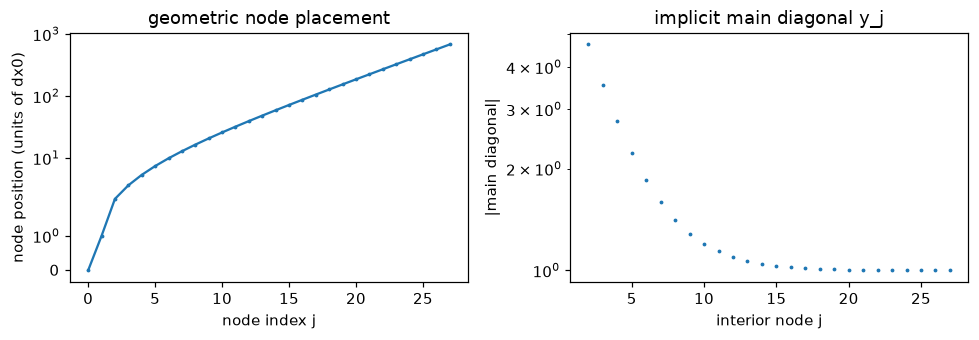

In [2]:
# Node spacing grows geometrically; a few hundred nodes reach far into the bulk.
a, DM, n = 1.2, 2.0, 2**12
m = expanding_grid_points(n, a, DM)
x, y, z = expanding_diagonals(m, a, DM)
print(f'expanding grid: a={a}, DM={DM}, n={n} time steps  ->  m={m} spatial nodes')

# cumulative node positions x_j = sum of steps dx0 * a^(j-1)  (dx0 absorbed into DM)
j = np.arange(m)
node_x = np.cumsum(a ** np.maximum(j - 1, 0)) - 1.0
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(j, node_x, '.-', ms=3)
ax[0].set(xlabel='node index j', ylabel='node position (units of dx0)',
          title='geometric node placement')
ax[0].set_yscale('symlog')
ax[1].plot(np.arange(2, m), np.abs(y), '.', ms=3)
ax[1].set(xlabel='interior node j', ylabel='|main diagonal|',
          title='implicit main diagonal y_j', yscale='log')
fig.tight_layout(); plt.show()

## 2. Quasi-reversible AC voltammetry

The surface is closed with the Butler-Volmer elimination (identical to Chapter 6, but
applied on the expanding grid). A sinusoid of dimensionless amplitude $f\,\Delta E$ and
dimensionless angular frequency $\Omega$ rides a linear DC ramp; the standard rate
constant $k_s$ tunes reversibility through the grid-scaled $k_s^{*}$.

AC run: n_cycles = 64.02, dtau = 0.0049, dE = 0.1946


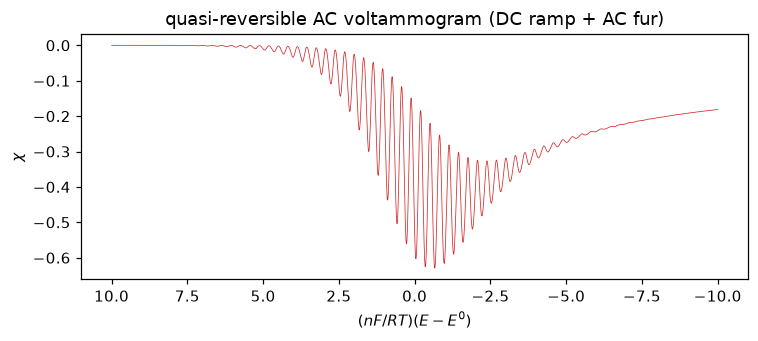

In [3]:
ac = simulate_ac(ks=1e3, amp_volt=0.005, Omega=6.4*np.pi, n=2**12)
print(f'AC run: n_cycles = {ac.n_cycles:.2f}, dtau = {ac.dtau:.4f}, dE = {ac.dE_dimless:.4f}')

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(ac.eta_dc, ac.chi, lw=0.5, color='C3')
ax.set(xlabel=r'$(nF/RT)(E-E^0)$', ylabel=r'$\chi$',
       title='quasi-reversible AC voltammogram (DC ramp + AC fur)')
ax.invert_xaxis(); fig.tight_layout(); plt.show()

### 2.1 Reduction to the validated reversible limit ($k_s\to\infty$)

Isolating the **fundamental harmonic** (band-pass around the $\Omega$ bin) and taking its
envelope, the reversible AC theory predicts a symmetric peak
$\tfrac14\,\mathrm{sech}^2(\eta/2)$ of height $\tfrac14$ centred at $E^0$. Our
expanding-grid BV simulator with large $k_s$ must reproduce it -- the same target the
chapter notebook validates against, here recovered through the BV boundary. **(Tier 2:
reduction to a validated limit.)**

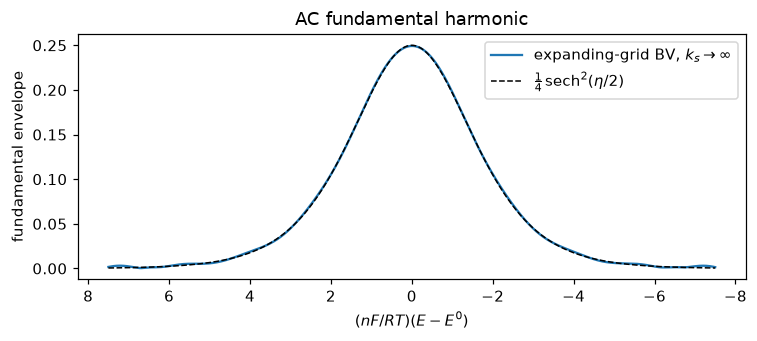

peak=0.2493 (target 0.25)  pos=-0.0073 (target 0)  max dev=0.0057


In [4]:
def isolate_fundamental(chi, n_cycles, half_width=12):
    '''Band-pass the FFT around the fundamental bin n_cycles and return the real signal.'''
    A = np.fft.fft(np.nan_to_num(chi)); N = len(A)
    c = int(round(n_cycles)); mask = np.zeros(N, complex)
    mask[c-half_width:c+half_width+1] = A[c-half_width:c+half_width+1]
    mask[N-(c+half_width):N-(c-half_width)+1] = A[N-(c+half_width):N-(c-half_width)+1]
    return np.real(np.fft.ifft(mask))

Omega = 6.4*np.pi
h1 = isolate_fundamental(ac.chi, ac.n_cycles)
env = np.abs(hilbert(h1)) * (1.0/np.sqrt(Omega)) / ac.dE_dimless
sl = slice(len(ac.chi)//8, 7*len(ac.chi)//8)        # drop FFT edge transients
eta_in, env_in = ac.eta_dc[sl], env[sl]
analytic = 0.25 / np.cosh(eta_in/2.0)**2

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(eta_in, env_in, color='C0', label=r'expanding-grid BV, $k_s\to\infty$')
ax.plot(eta_in, analytic, 'k--', lw=1, label=r'$\frac{1}{4}\,\mathrm{sech}^2(\eta/2)$')
ax.set(xlabel=r'$(nF/RT)(E-E^0)$', ylabel='fundamental envelope', title='AC fundamental harmonic')
ax.legend(); ax.invert_xaxis(); fig.tight_layout(); plt.show()

core = np.abs(eta_in) < 4.0
dev = np.max(np.abs(env_in[core]-analytic[core])) / analytic[core].max()
peak = env_in[core].max(); pos = eta_in[np.argmax(env_in)]
print(f'peak={peak:.4f} (target 0.25)  pos={pos:+.4f} (target 0)  max dev={dev:.4f}')

### 2.2 Kinetic broadening

Lowering $k_s$ moves the couple from reversible toward irreversible; the AC fundamental
peak must shrink **monotonically** (less charge can follow the perturbation). This is a
self-consistency check that the BV boundary is doing real kinetics, not just reproducing
the reversible limit.

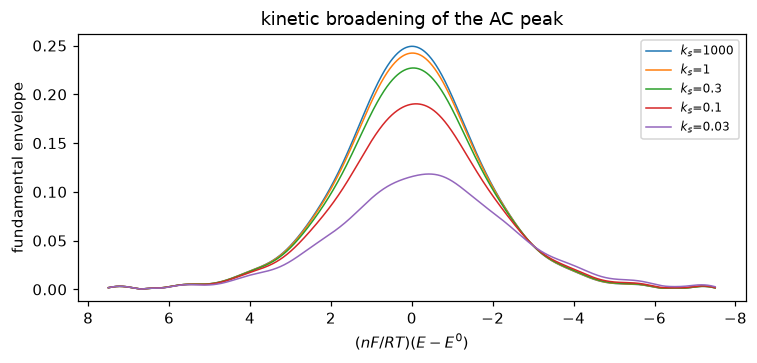

peaks vs ks: {1000.0: np.float64(0.2493), 1.0: np.float64(0.2424), 0.3: np.float64(0.2271), 0.1: np.float64(0.1903), 0.03: np.float64(0.1183)}


In [5]:
ks_values = [1e3, 1.0, 0.3, 0.1, 0.03]
peaks = []
fig, ax = plt.subplots(figsize=(7, 3.4))
for ks in ks_values:
    r = simulate_ac(ks=ks, n=2**12)
    h = isolate_fundamental(r.chi, r.n_cycles)
    e = np.abs(hilbert(h)) * (1.0/np.sqrt(Omega)) / r.dE_dimless
    s = slice(len(r.chi)//8, 7*len(r.chi)//8)
    ax.plot(r.eta_dc[s], e[s], lw=1, label=f'$k_s$={ks:g}')
    peaks.append(e[s].max())
ax.set(xlabel=r'$(nF/RT)(E-E^0)$', ylabel='fundamental envelope', title='kinetic broadening of the AC peak')
ax.legend(fontsize=8); ax.invert_xaxis(); fig.tight_layout(); plt.show()
print('peaks vs ks:', dict(zip(ks_values, np.round(peaks, 4))))

## 3. The moving-average DC filter

Averaging the raw AC current over one full AC cycle removes the ripple and leaves the DC
(linear-sweep) response. Honeychurch passes a flat-window moving average twice;
`ac_dc_filter` wraps `serm.filters.moving_average`. The DC-filtered peak is an
**independent closed-form check**: a reversible DC linear-sweep voltammogram peaks at the
dimensionless value $0.4463$ (Nicholson-Shain / Randles-Sevcik), so the filtered AC
response (which is reversible at large $k_s$) must peak there. **(Tier 1: closed-form
analytic reference.)**

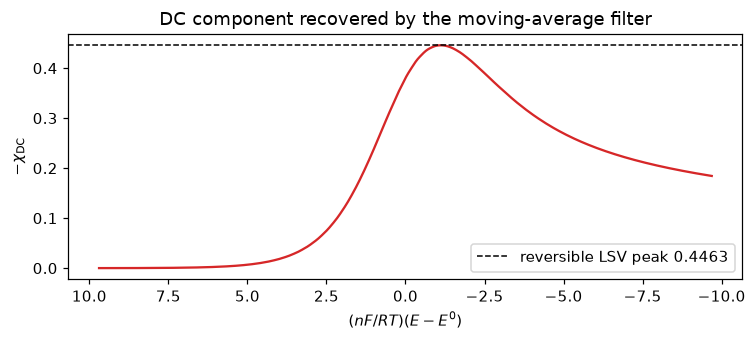

DC-filtered peak = 0.4457  (reversible LSV target 0.4463)


In [6]:
npc = int(round(len(ac.chi) / ac.n_cycles))           # increments per AC cycle
filt, overhang = ac_dc_filter(ac.chi, npc, passes=2)
eta_filt = ac.eta_dc[overhang//2 : overhang//2 + len(filt)]   # re-align after the moving average

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(eta_filt, -filt, color='C3')
ax.axhline(0.4463, color='k', ls='--', lw=1, label='reversible LSV peak 0.4463')
ax.set(xlabel=r'$(nF/RT)(E-E^0)$', ylabel=r'$-\chi_{\rm DC}$',
       title='DC component recovered by the moving-average filter')
ax.legend(); ax.invert_xaxis(); fig.tight_layout(); plt.show()

dc_peak = -filt.min()
print(f'DC-filtered peak = {dc_peak:.4f}  (reversible LSV target 0.4463)')

## 4. Square-wave voltammetry

Same engine, square-wave excitation. Two waveforms:

* **SW on a linear ramp** (`simulate_sw_ramp`, from `ImplicitSWExp1.nb`) -- the DC base is
  a smooth ramp;
* **SW on a staircase** (`simulate_sw_staircase`, from `ImplicitSWExp2.nb`) -- true SWV,
  where the DC base steps once per square-wave cycle.

Current is sampled at the end of each forward and reverse pulse; the **difference
current** $\Delta\chi=\chi_{\rm f}-\chi_{\rm b}$ is the analytical SWV response -- a peak
centred on the formal potential.

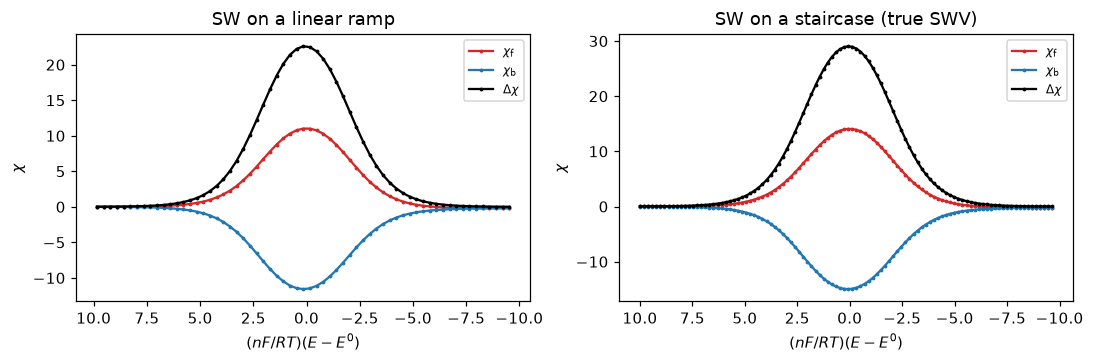

ramp     : |dchi|peak=22.589 at eta=+0.156, cycles=64
staircase: |dchi|peak=29.048 at eta=+0.075, cycles=103


In [7]:
sw_r = simulate_sw_ramp(ks=1e3, tN=50)
sw_s = simulate_sw_staircase(ks=1e3, tN=50)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), sharey=False)
for a_, sw, ttl in [(ax[0], sw_r, 'SW on a linear ramp'),
                    (ax[1], sw_s, 'SW on a staircase (true SWV)')]:
    a_.plot(sw.eta_sample, sw.chi_forward,  '.-', ms=3, color='C3', label=r'$\chi_{\rm f}$')
    a_.plot(sw.eta_sample, sw.chi_backward, '.-', ms=3, color='C0', label=r'$\chi_{\rm b}$')
    a_.plot(sw.eta_sample, sw.chi_diff,     '.-', ms=3, color='k',  label=r'$\Delta\chi$')
    a_.set(xlabel=r'$(nF/RT)(E-E^0)$', ylabel=r'$\chi$', title=ttl)
    a_.legend(fontsize=8); a_.invert_xaxis()
fig.tight_layout(); plt.show()

for name, sw in [('ramp', sw_r), ('staircase', sw_s)]:
    ipk = np.argmax(np.abs(sw.chi_diff))
    print(f'{name:9s}: |dchi|peak={np.abs(sw.chi_diff).max():.3f} at eta={sw.eta_sample[ipk]:+.3f}, cycles={sw.n_cycles}')

### 4.1 SW kinetic trend

As with AC, lowering $k_s$ must reduce the SW difference-current peak height
(quasi-reversibility). A monotone-decreasing trend is the self-consistency check for the
SW BV boundary.

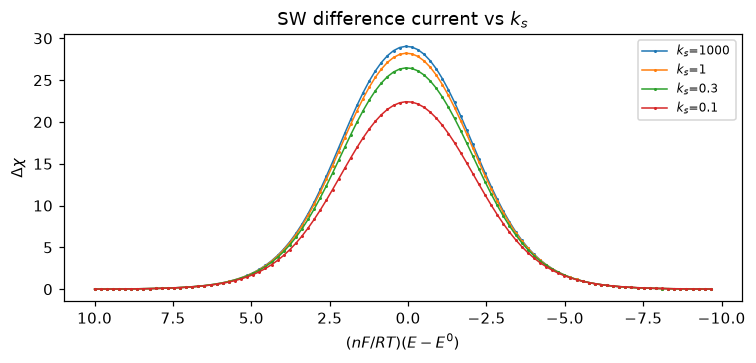

SW diff peaks vs ks: {1000.0: np.float64(29.048), 1.0: np.float64(28.227), 0.3: np.float64(26.469), 0.1: np.float64(22.423)}


In [8]:
ks_values = [1e3, 1.0, 0.3, 0.1]
sw_peaks = []
fig, ax = plt.subplots(figsize=(7, 3.4))
for ks in ks_values:
    sw = simulate_sw_staircase(ks=ks, tN=50)
    ax.plot(sw.eta_sample, sw.chi_diff, '.-', ms=2, lw=1, label=f'$k_s$={ks:g}')
    sw_peaks.append(np.abs(sw.chi_diff).max())
ax.set(xlabel=r'$(nF/RT)(E-E^0)$', ylabel=r'$\Delta\chi$', title='SW difference current vs $k_s$')
ax.legend(fontsize=8); ax.invert_xaxis(); fig.tight_layout(); plt.show()
print('SW diff peaks vs ks:', dict(zip(ks_values, np.round(sw_peaks, 3))))

## 5. FFT analysis of the square-wave voltammogram

The raw SW current is a periodic train at the square-wave frequency. Its power spectrum
peaks at the fundamental bin (number of SW cycles) with weaker harmonics -- the
frequency-domain analogue of the harmonic structure seen for AC. We confirm the
fundamental sits at the expected bin.

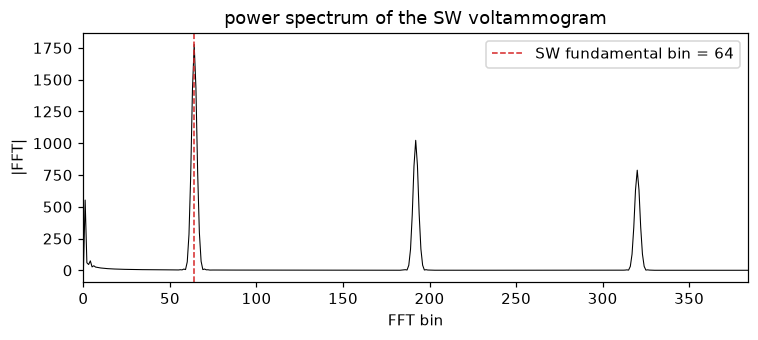

SW FFT fundamental bin = 64  (expected 64, ratio 1.0000)


In [9]:
sw = simulate_sw_ramp(ks=1e3, tN=50)
chi = np.nan_to_num(sw.chi_full - np.nanmean(sw.chi_full))
N = len(chi)
A = np.abs(np.fft.fft(chi))
bins = np.arange(N)

half = N // 2
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(bins[:half], A[:half], color='k', lw=0.7)
ax.axvline(sw.n_cycles, color='C3', ls='--', lw=1, label=f'SW fundamental bin = {sw.n_cycles}')
ax.set(xlabel='FFT bin', ylabel='|FFT|', title='power spectrum of the SW voltammogram',
       xlim=(0, 6*sw.n_cycles))
ax.legend(); fig.tight_layout(); plt.show()

lo = sw.n_cycles // 2
ipk = int(np.argmax(A[lo:half]) + lo)
print(f'SW FFT fundamental bin = {ipk}  (expected {sw.n_cycles}, ratio {ipk/sw.n_cycles:.4f})')

## 6. Validation

Collecting the assert-backed checks, strongest first.

In [10]:
# --- Tier 2: reduction to a validated limit ---
# (a) the shared BV elimination still reproduces both kinetic limits
bv_limits_selfcheck()

# (b) expanding-grid AC fundamental -> reversible (1/4) sech^2(eta/2) as ks -> inf
ac_v = simulate_ac(ks=1e6, n=2**12, Omega=6.4*np.pi, amp_volt=0.005)
h1 = isolate_fundamental(ac_v.chi, ac_v.n_cycles)
env = np.abs(hilbert(h1)) * (1.0/np.sqrt(6.4*np.pi)) / ac_v.dE_dimless
s = slice(len(ac_v.chi)//8, 7*len(ac_v.chi)//8)
e_in, env_in = ac_v.eta_dc[s], env[s]
core = np.abs(e_in) < 4.0
analytic = 0.25/np.cosh(e_in/2.0)**2
line_dev = np.max(np.abs(env_in[core]-analytic[core]))/analytic[core].max()
peak_val = env_in[core].max(); peak_pos = e_in[np.argmax(env_in)]
print(f'(b) AC fundamental: dev={line_dev:.4f}, peak={peak_val:.4f}, pos={peak_pos:+.4f}')
assert line_dev < 0.05,            f'AC fundamental lineshape off by {line_dev:.3f}'
assert abs(peak_val-0.25) < 0.02,  f'AC peak {peak_val:.4f} not ~1/4'
assert abs(peak_pos) < 0.10,       f'AC peak not at E0 (eta={peak_pos:.3f})'

# --- Tier 1: closed-form analytic reference ---
# DC-filtered AC peak == reversible LSV peak 0.4463 (Nicholson-Shain)
npc = int(round(len(ac_v.chi)/ac_v.n_cycles))
filt, _ = ac_dc_filter(ac_v.chi, npc, passes=2)
dc_peak = -filt.min()
print(f'DC-filtered peak = {dc_peak:.4f} (target 0.4463)')
assert abs(dc_peak - 0.4463) < 0.02, f'DC-filtered peak {dc_peak:.4f} != reversible 0.4463'

print('PASS: ks->inf recovers reversible AC fundamental AND DC-filtered LSV peak (0.4463)')

(b) AC fundamental: dev=0.0057, peak=0.2493, pos=-0.0073
DC-filtered peak = 0.4457 (target 0.4463)
PASS: ks->inf recovers reversible AC fundamental AND DC-filtered LSV peak (0.4463)


In [11]:
# --- Tier 3: self-consistency ---
# (c) AC fundamental peak decreases monotonically as ks falls (kinetic broadening)
peaks = []
for ks in [1e3, 1.0, 0.3, 0.1, 0.03, 0.01]:
    r = simulate_ac(ks=ks, n=2**12)
    h = isolate_fundamental(r.chi, r.n_cycles)
    ev = np.abs(hilbert(h)) * (1.0/np.sqrt(6.4*np.pi)) / r.dE_dimless
    sl = slice(len(r.chi)//8, 7*len(r.chi)//8)
    peaks.append(ev[sl].max())
print('AC peaks vs ks:', np.round(peaks, 4))
assert np.all(np.diff(peaks) < 0), 'AC peak not monotone-decreasing in ks'
# ks -> 0 (strongly irreversible) limit: the AC fundamental must COLLAPSE well
# below the reversible 1/4, not merely shift -- the sluggish electrode cannot
# follow the fast AC perturbation. (Complements the ks -> inf reversible limit.)
assert peaks[0] > 0.24, f'reversible AC peak {peaks[0]:.4f} should be ~1/4'
assert peaks[-1] < 0.5 * peaks[0], (
    f'strongly-irreversible AC peak {peaks[-1]:.4f} should collapse to <50% of '
    f'the reversible {peaks[0]:.4f}')

# (d) SW difference peak sits at the formal potential and decreases with ks
sw_peaks = []
for ks in [1e3, 1.0, 0.3, 0.1]:
    sw = simulate_sw_staircase(ks=ks, tN=50)
    ipk = np.argmax(np.abs(sw.chi_diff))
    assert abs(sw.eta_sample[ipk]) < 0.5, f'SW diff peak off E0 (eta={sw.eta_sample[ipk]:.3f})'
    sw_peaks.append(np.abs(sw.chi_diff).max())
print('SW diff peaks vs ks:', np.round(sw_peaks, 3))
assert np.all(np.diff(sw_peaks) < 0), 'SW diff peak not monotone-decreasing in ks'

# (e) FFT fundamental of the SW voltammogram lands on the cycle-count bin
sw = simulate_sw_ramp(ks=1e3, tN=50)
A = np.abs(np.fft.fft(np.nan_to_num(sw.chi_full - np.nanmean(sw.chi_full))))
half = len(A)//2; lo = sw.n_cycles//2
ipk = int(np.argmax(A[lo:half]) + lo)
print(f'SW FFT fundamental bin = {ipk} (expected {sw.n_cycles})')
assert abs(ipk - sw.n_cycles) <= 1, f'SW FFT fundamental at bin {ipk}, expected {sw.n_cycles}'

print('PASS: kinetic broadening (AC & SW), SW peak at E0, SW FFT fundamental on bin')

AC peaks vs ks: [0.2493 0.2424 0.2271 0.1903 0.1183 0.0606]


SW diff peaks vs ks: [29.048 28.227 26.469 22.423]
SW FFT fundamental bin = 64 (expected 64)
PASS: kinetic broadening (AC & SW), SW peak at E0, SW FFT fundamental on bin


## 7. Summary

The quasi-reversible Butler-Volmer AC and square-wave simulators run on an exponentially
expanding space grid, reusing the chapter's already-validated surface elimination. As
$k_s\to\infty$ the expanding-grid AC fundamental recovers the reversible
$\tfrac14\,\mathrm{sech}^2(\eta/2)$ envelope and the moving-average DC filter recovers the
reversible LSV peak $0.4463$; finite $k_s$ broadens both the AC and SW peaks
monotonically; and the FFT of the SW voltammogram locates the fundamental on the
cycle-count bin. The waveform is the only thing that changes between AC, SW-on-ramp and
SW-on-staircase, all of which share one solver in
`serm.ch07_quasireversible_ac_sw`.

<!-- nav-footer -->

---

[← Chapter 7 — AC Voltammetry](../07_ac_voltammetry.ipynb)

[Contents (README)](../../README.md)